# Objective : Objective: Learn Python basics and perform basic data exploration and cleaning using Pandas.

## Dataset
Dataset Used: `combined_dataset.csv`

The dataset contains product-related information such as prices, ratings, categories, and other attributes useful for analysis.

## Tasks Performed
1. Load the dataset into a Pandas DataFrame.
2. Explore the dataset structure and summary statistics.
3. Identify and handle missing values.
4. Remove duplicate records.
5. Convert data types where necessary.
6. Create derived features:
   - Price Difference
   - Popularity Metric
7. Perform exploratory data analysis (EDA).
8. Create visualizations to understand trends and patterns.
9. Generate business insights.
10. Save the cleaned dataset as a new CSV file.

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Expected Outputs
- Cleaned Dataset (`cleaned_dataset.csv`)
- Data Analysis Notebook (`analysis.ipynb`)
- Summary of Findings and Insights

## Step 1: Load Data

* Import required libraries: pandas, numpy, matplotlib, seaborn
* Load the dataset
* Check dataset shape and column names

In [42]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/combined_dataset.csv")

In [43]:
print(df) # display dataset 

     product_id           title  \
0       8376765     Lino Perros   
1       9136281  Tommy Hilfiger   
2      17633752           Lavie   
3       1376949          F Gear   
4      13939916       MYTRIDENT   
..          ...             ...   
995    13698258           KREDO   
996    16896006           GUESS   
997     1708108        GIORDANO   
998    19280114        Fastrack   
999    18601682         BOLDFIT   

                                   product_description  rating  ratings_count  \
0                       Women Navy Blue Solid Backpack     3.8             15   
1                    Unisex Navy Blue Striped Backpack     4.5             67   
2                       Aries Women Pink Mini Backpack     4.4            226   
3           Unisex Navy & Grey Printed Burner Backpack     4.4           1052   
4                             Men Blue Solid Bath Robe     4.7             12   
..                                                 ...     ...            ...   
995  Men FOR

In [44]:
print(df.head())  # display first 5 records

   product_id           title                         product_description  \
0     8376765     Lino Perros              Women Navy Blue Solid Backpack   
1     9136281  Tommy Hilfiger           Unisex Navy Blue Striped Backpack   
2    17633752           Lavie              Aries Women Pink Mini Backpack   
3     1376949          F Gear  Unisex Navy & Grey Printed Burner Backpack   
4    13939916       MYTRIDENT                    Men Blue Solid Bath Robe   

   rating  ratings_count  initial_price  discount  final_price currency  \
0     3.8             15           3995      58.0  "₹3,995.00"      INR   
1     4.5             67           2899      35.0  "₹2,899.00"      INR   
2     4.4            226           2999      65.0  "₹2,999.00"      INR   
3     4.4           1052           1675      52.0  "₹1,675.00"      INR   
4     4.7             12           2899      17.0  "₹2,899.00"      INR   

                                              images  ...  \
0  http://assets.myntasse

In [45]:
# Dataset shape
print("Dataset Shape: ", df.shape)

# display Dataset Columns
print("\nColumn names:")
for col in df.columns:
    print(col)

Dataset Shape:  (1000, 24)

Column names:
product_id
title
product_description
rating
ratings_count
initial_price
discount
final_price
currency
images
delivery_options
product_details
breadcrumbs
product_specifications
amount_of_stars
what_customers_said
seller_name
sizes
videos
seller_information
variations
best_offer
more_offers
category


## Step 2: Understand Data
* Check data types of all columns
* Identify missing/null values
* Use .info() and .describe() for summary statistics

In [46]:
# Data types of all columns
print("Data Types:", df.dtypes)

Data Types: product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes                      object
videos                     object
seller_information         object
variations                 object
best_offer                 object
more_offers                object
category                   object
dtype: object


In [47]:
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   object 
 2   product_description     1000 non-null   object 
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   object 
 8   currency                1000 non-null   object 
 9   images                  1000 non-null   object 
 10  delivery_options        1000 non-null   object 
 11  product_details         1000 non-null   object 
 12  breadcrumbs             1000 non-null   object 
 13  product_specifications  1000 non-null   object 
 14  amount_of_stars      

In [48]:
# Count Missing Values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Total Missing Values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Missing Values Percentage
print("\nMissing Value Persentage:\n",((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False))


Missing Values in Each Column:
product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64

Total Missing Values: 2639

Missing Value Persentage:
 videos                    78.1
what_customers_said       57.3
variations                56.2
seller_information        30.1
seller_name               30.1
discount                

In [49]:
# Summary Statistics for Numerical Columns
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


In [50]:
# Summary Statistics for All Columns
df.describe(include = "all")

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
count,1.000000e+03,1000,1000,1000.0000,1000.000000,1000.00000,879.000000,1000,1000,1000,...,1000,427,699,1000,219,699,438,1000,1000,1000
unique,NaN,454,989,NaN,NaN,NaN,NaN,466,1,1000,...,808,302,301,672,219,298,22,468,159,97
top,NaN,Roadster,Women Pink Solid Top,NaN,NaN,NaN,NaN,"""₹999.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...","[{""percentage"":""100"",""value_name"":""Fit, Just R...",Sup███om ███,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",Plo███o- ███ 1s█████████Sui███████████████████...,[{}],{},"[{""offer_name"":""10% Instant Discount on IndusI...",tops
freq,NaN,30,3,NaN,NaN,NaN,NaN,25,1000,1,...,114,27,40,135,1,40,126,306,265,122
mean,1.713437e+07,NaN,NaN,3.6215,76.691000,2723.24100,53.503982,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.813766e+06,NaN,NaN,1.3744,241.114263,2408.69736,18.029201,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,5.868460e+05,NaN,NaN,0.0000,0.000000,249.00000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.511501e+07,NaN,NaN,3.7000,7.000000,1399.00000,44.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.820890e+07,NaN,NaN,4.1000,17.000000,1999.00000,56.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.902737e+07,NaN,NaN,4.3000,58.000000,3299.00000,66.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# check unique values
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

product_id : 1000 unique values
title : 454 unique values
product_description : 989 unique values
rating : 34 unique values
ratings_count : 221 unique values
initial_price : 256 unique values
discount : 81 unique values
final_price : 466 unique values
currency : 1 unique values
images : 1000 unique values
delivery_options : 16 unique values
product_details : 998 unique values
breadcrumbs : 658 unique values
product_specifications : 967 unique values
amount_of_stars : 808 unique values
what_customers_said : 302 unique values
seller_name : 301 unique values
sizes : 672 unique values
videos : 219 unique values
seller_information : 298 unique values
variations : 22 unique values
best_offer : 468 unique values
more_offers : 159 unique values
category : 97 unique values


## Step 3: Data Cleaning
* Convert price-related columns to numeric format
* Handle missing values appropriately (drop/fill)
* Remove duplicate records

In [52]:
# Convert Price Columns to Numeric Format
df['final_price'].head()

# Remove commas, special symbols and convert to numeric
df['final_price'] = (
    df['final_price']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')

In [53]:
print(df[['initial_price', 'final_price']].dtypes)

initial_price      int64
final_price      float64
dtype: object


In [54]:
# Handle Missing Values

# Discount Column (Numerical data)
df['discount'] = df['discount'].fillna(0)

# Text Columns (Categorical data)
text_cols = [
    'what_customers_said',
    'seller_name',
    'seller_information',
    'variations',
    'videos'
]

for col in text_cols:
    df[col] = df[col].fillna('Not Available')

In [55]:
print(df.isnull().sum())  # verify

product_id                0
title                     0
product_description       0
rating                    0
ratings_count             0
initial_price             0
discount                  0
final_price               0
currency                  0
images                    0
delivery_options          0
product_details           0
breadcrumbs               0
product_specifications    0
amount_of_stars           0
what_customers_said       0
seller_name               0
sizes                     0
videos                    0
seller_information        0
variations                0
best_offer                0
more_offers               0
category                  0
dtype: int64


In [56]:
# Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

# Remove
df.drop_duplicates(inplace=True)

print("\nDataset Shape:")
print(df.shape)

Duplicate Rows: 0

Dataset Shape:
(1000, 24)


## Step 4: Feature Engineering
* Create a **price difference column** (initial price vs final price)
*  Create a **popularity metric** (using rating and ratings count
  * Extract useful information from complex fields if requireded

In [57]:
# Create a price diffrence column
df['price_difference'] = df['initial_price'] - df['final_price']
df[['initial_price', 'final_price', 'price_difference']].head(20)

,initial_price,final_price,price_difference
0,3995,3995.0,0.0
1,2899,2899.0,0.0
2,2999,2999.0,0.0
3,1675,1675.0,0.0
4,2899,2899.0,0.0
5,1399,1399.0,0.0
6,1399,1399.0,0.0
7,2999,2999.0,0.0
8,2999,2999.0,0.0
9,2199,2199.0,0.0


In [58]:
# Create popularity Metric
df['popularity_metric'] = df['rating'] * df['ratings_count']
df[['rating', 'ratings_count', 'popularity_metric']].head()

,rating,ratings_count,popularity_metric
0,3.8,15,57.0
1,4.5,67,301.5
2,4.4,226,994.4
3,4.4,1052,4628.8
4,4.7,12,56.4


In [59]:
# Extract meaningful information
df['description_length'] = df['product_description'].str.len()
df[['product_description', 'description_length']].head()

,product_description,description_length
0,Women Navy Blue Solid Backpack,30
1,Unisex Navy Blue Striped Backpack,33
2,Aries Women Pink Mini Backpack,30
3,Unisex Navy & Grey Printed Burner Backpack,42
4,Men Blue Solid Bath Robe,24


In [60]:
# Discount Percentage
df['discount_percentage'] = (
    (df['initial_price'] - df['final_price']) / df['initial_price']
) * 100

# Price Category
df['price_category'] = pd.cut(
    df['final_price'],
    bins=[0, 1000, 3000, 5000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

df[['discount_percentage','price_category']].head()

,discount_percentage,price_category
0,0.0,Premium
1,0.0,Mid-Range
2,0.0,Mid-Range
3,0.0,Mid-Range
4,0.0,Mid-Range


## Step 5: Analysis

* Perform **Univariate Analysis** (single variable)
* Perform **Bivariate Analysis** (relationship between variables)
* Conduct **Category-level Analysis** for insights


count    1000.0000
mean        3.6215
std         1.3744
min         0.0000
25%         3.7000
50%         4.1000
75%         4.3000
max         5.0000
Name: rating, dtype: float64


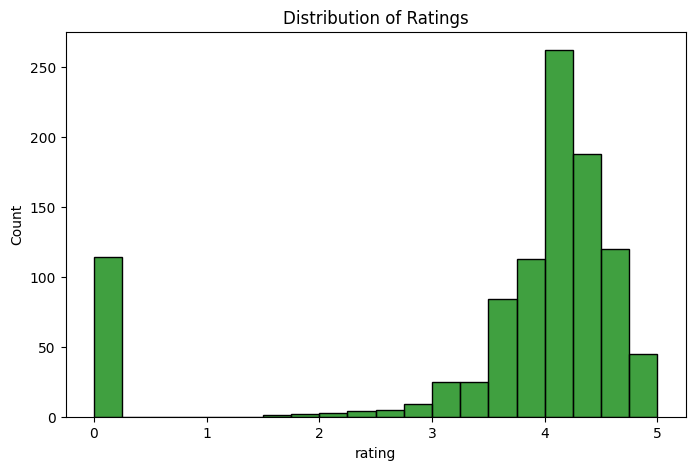

In [61]:
# Univariate Analysis

# Rating Distribution
print(df['rating'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins = 20, color = 'green')
plt.title('Distribution of Ratings')
plt.show()

count     1000.000000
mean      1706.096000
std       1783.864472
min        199.000000
25%        649.000000
50%       1099.000000
75%       2082.250000
max      17995.000000
Name: final_price, dtype: float64


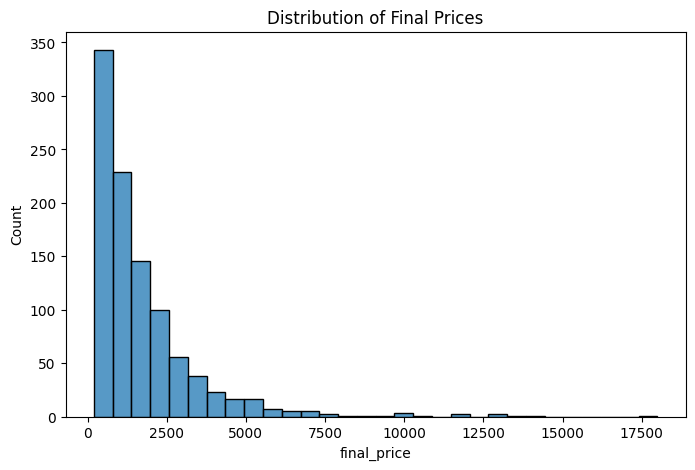

In [62]:
# Final Price Distribution
print(df['final_price'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['final_price'], bins=30)
plt.title('Distribution of Final Prices')
plt.show()

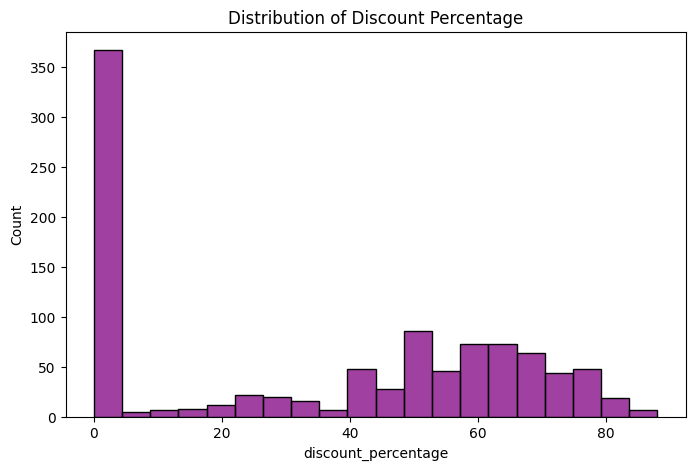

In [63]:
# Discount percentage Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['discount_percentage'], bins=20, color = "purple")
plt.title('Distribution of Discount Percentage')
plt.show()

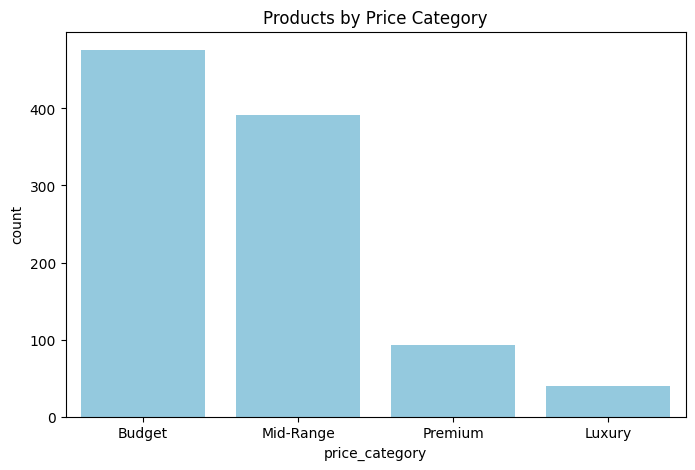

In [64]:
# Price Category Count
df['price_category'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(x = 'price_category', data=df , color = 'skyblue')
plt.title('Products by Price Category')
plt.show()

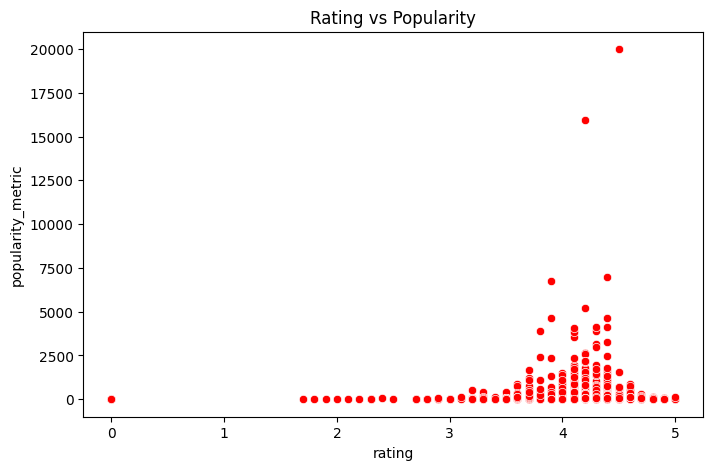

In [67]:
# Bivaraite Analysis

# Rating Vs Popularity
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'rating', y = 'popularity_metric', data = df , color = 'red')
plt.title('Rating vs Popularity')
plt.show()

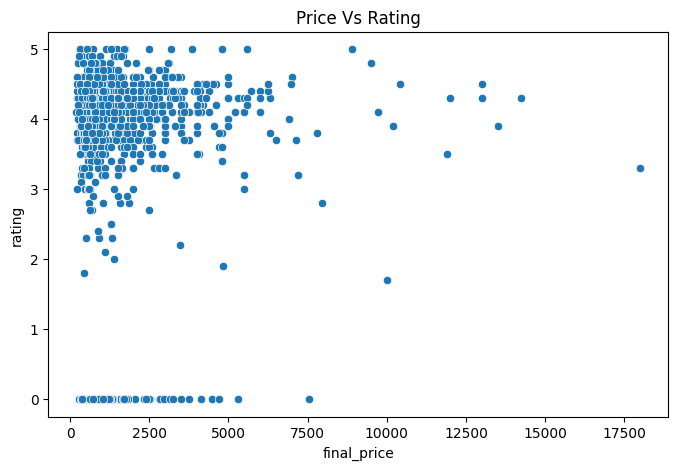

In [68]:
# Final Price vs Rating
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'final_price' , y = 'rating' , data = df)
plt.title("Price Vs Rating")
plt.show()

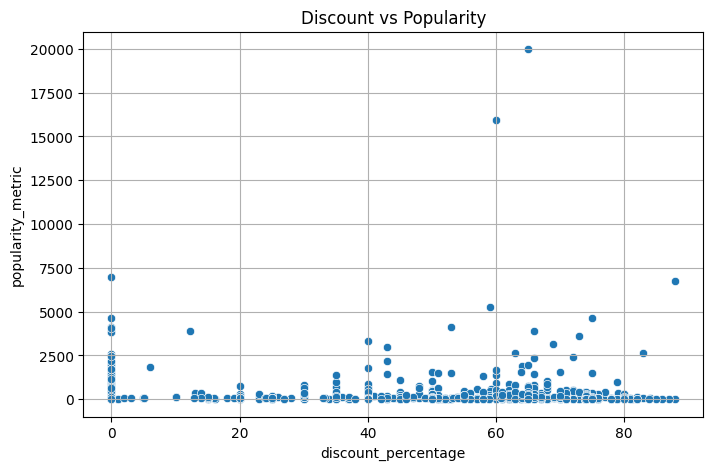

In [71]:
# Discount Percentage vs Popularity
plt.figure(figsize=(8,5))
sns.scatterplot( x = 'discount_percentage', y = 'popularity_metric', data = df)
plt.title('Discount vs Popularity')
plt.grid()
plt.show()

category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
tshirts          39
earrings         34
sweaters         34
jackets          29
casual-shoes     23
Name: count, dtype: int64


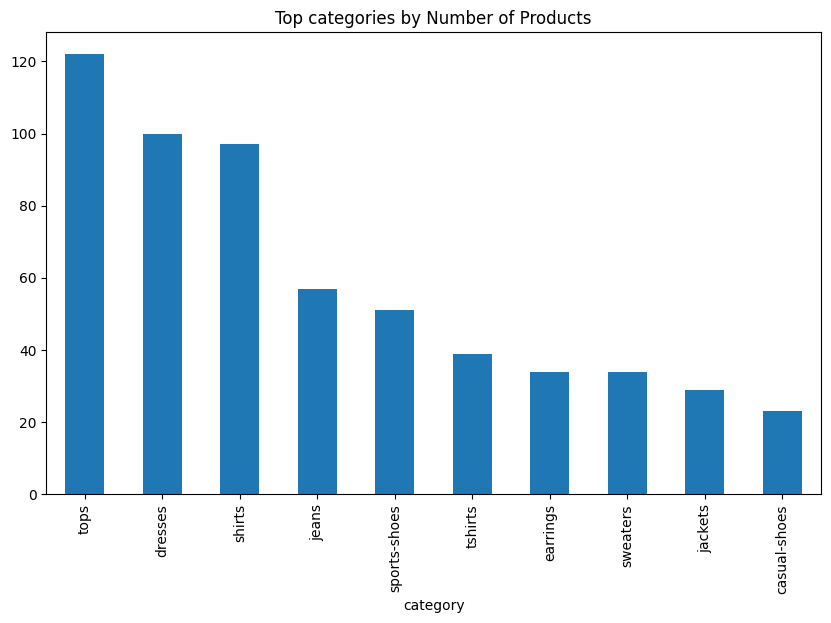

In [72]:
# Category - level Analysis

# Products per category
category_count = df['category'].value_counts()
print(category_count.head(10))
plt.figure(figsize = (10,6))
category_count.head(10).plot(kind = 'bar')
plt.title('Top categories by Number of Products')
plt.show()